# Task 7 - ETF Data Pipeline: Exploratory Data Analysis

Sanity checks and report figures for the Phase 1 dataset that feeds the LSTM
forecaster (windowed arrays) and the optimiser / baselines / backtester
(aligned price + return panels).

This notebook is **read-only**: it imports `src.data` and inspects the
artifacts already written to `data/processed/`. Rebuild them first with:

```
python -m src.data.pipeline          # from the repo root; uses data/cache/
python -m src.data.pipeline --refresh   # re-download from Yahoo
```

**Design (locked):** 8 ETFs - SPY, QQQ, EFA, EEM, AGG, IEF, GLD, VNQ -
2010-01-01 to 2024-12-31 (fetched from 2009-06-01 as lookback warmup),
6 causal features, 30-day windows pooled across sleeves, two targets
(`ret_next`, `fwd_vol` over 20 trading days), purged splits, seed 42.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Make the repo root importable regardless of where the kernel was started.
ROOT = Path.cwd()
if not (ROOT / "src" / "data").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import config
from src.data.crosscheck import stooq_compare, tick_screen
from src.data.features import build_features_by_ticker
from src.data.fetch import coverage_report, fetch_prices
from src.data.pipeline import load_split
from src.data.targets import build_targets_by_ticker

pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.random.seed(config.SEED)

print(f"repo root : {ROOT}")
print(f"universe  : {config.UNIVERSE}")
print(f"window    : {config.WINDOW}d   vol horizon: {config.VOL_HORIZON}d   seed: {config.SEED}")
print(f"features  : {config.FEATURE_ORDER}")

repo root : C:\Users\tianc\Desktop\Final Project\etf-advisor
universe  : ['SPY', 'QQQ', 'EFA', 'EEM', 'AGG', 'IEF', 'GLD', 'VNQ']
window    : 30d   vol horizon: 20d   seed: 42
features  : ['ret', 'vol_10', 'mom_5', 'mom_20', 'px_ma20', 'px_ma50']


In [2]:
# Load every artifact the pipeline produced.
prices_raw = fetch_prices(config.UNIVERSE, config.FETCH_START, config.FETCH_END,
                          config.CACHE_DIR, refresh=False)      # cache only, no network
panel   = pd.read_parquet(config.PROCESSED_DIR / "prices.parquet")
returns = pd.read_parquet(config.PROCESSED_DIR / "returns.parquet")
meta    = pd.read_parquet(config.PROCESSED_DIR / "meta.parquet")
scaler  = joblib.load(config.PROCESSED_DIR / "scaler.joblib")
splits  = {s: load_split(s) for s in ("train", "val", "test")}

print(f"prices  {panel.shape}   {panel.index.min():%Y-%m-%d} .. {panel.index.max():%Y-%m-%d}")
print(f"returns {returns.shape}")
print(f"meta    {meta.shape}")

  [cache hit ] SPY   SPY.parquet
  [cache hit ] QQQ   QQQ.parquet
  [cache hit ] EFA   EFA.parquet
  [cache hit ] EEM   EEM.parquet
  [cache hit ] AGG   AGG.parquet
  [cache hit ] IEF   IEF.parquet
  [cache hit ] GLD   GLD.parquet
  [cache hit ] VNQ   VNQ.parquet


prices  (3924, 8)   2009-06-01 .. 2024-12-31
returns (3924, 8)
meta    (30608, 5)


## 1. Coverage

Per-ticker first/last date, row count, and any gap longer than five business
days (which would indicate a genuine missing stretch rather than a market
holiday).

In [3]:
cov = coverage_report(prices_raw)
display(cov.drop(columns=["gap_detail"]))

print(f"all start on or before 2009-06-05 : "
      f"{all(pd.Timestamp(d) <= pd.Timestamp('2009-06-05') for d in cov['first_date'])}")
print(f"all end on or after   2024-12-30 : "
      f"{all(pd.Timestamp(d) >= pd.Timestamp('2024-12-30') for d in cov['last_date'])}")
print(f"tickers with a gap > 5 business days: {int((cov['gaps_gt_5bd'] > 0).sum())}")

union = len(set().union(*[set(df.index) for df in prices_raw.values()]))
print(f"\nunion of all trading dates : {union}")
print(f"aligned panel (inner join) : {len(panel)}")
print(f"dates dropped by the join  : {union - len(panel)}")

,first_date,last_date,rows,max_cal_gap_days,gaps_gt_5bd
ticker,,,,,
SPY,2009-06-01,2024-12-31,3924,5,0
QQQ,2009-06-01,2024-12-31,3924,5,0
EFA,2009-06-01,2024-12-31,3924,5,0
EEM,2009-06-01,2024-12-31,3924,5,0
AGG,2009-06-01,2024-12-31,3924,5,0
IEF,2009-06-01,2024-12-31,3924,5,0
GLD,2009-06-01,2024-12-31,3924,5,0
VNQ,2009-06-01,2024-12-31,3924,5,0


all start on or before 2009-06-05 : True
all end on or after   2024-12-30 : True
tickers with a gap > 5 business days: 0

union of all trading dates : 3924
aligned panel (inner join) : 3924
dates dropped by the join  : 0


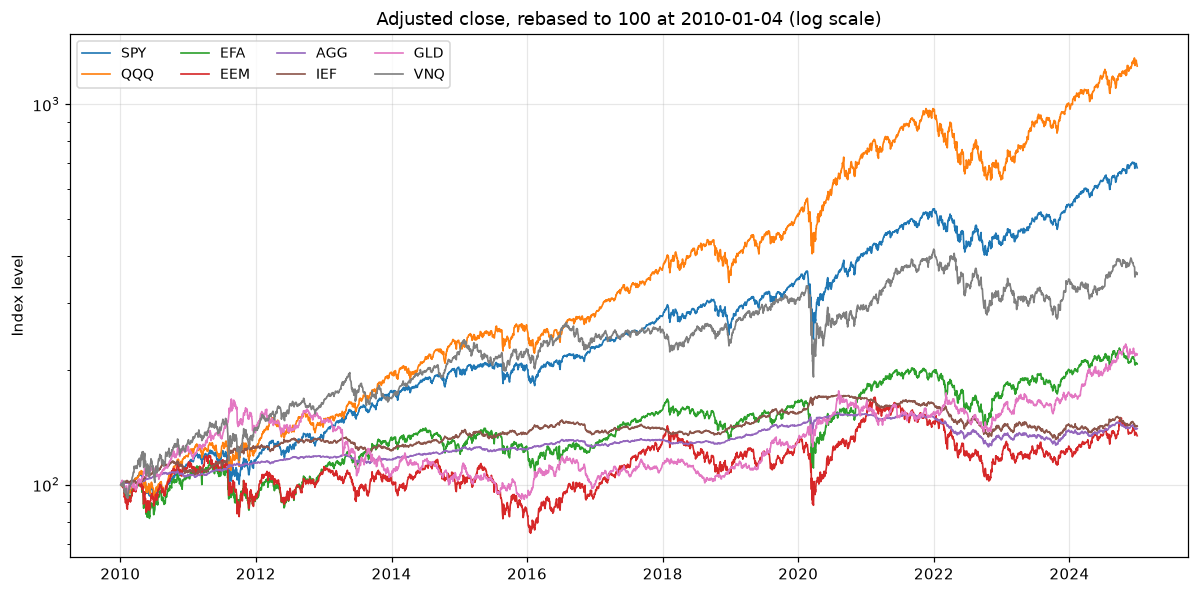

In [4]:
# Adjusted closes, rebased to 100 at the first evaluation date, so the eight
# sleeves are comparable on one axis.
base = panel.loc[panel.index >= config.EVAL_START]
rebased = base / base.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
for t in config.UNIVERSE:
    ax.plot(rebased.index, rebased[t], label=t, linewidth=1.1)
ax.set_yscale("log")
ax.set_title("Adjusted close, rebased to 100 at 2010-01-04 (log scale)")
ax.set_ylabel("Index level")
ax.legend(ncol=4, fontsize=9)
fig.tight_layout()
plt.show()

## 2. Correlation of daily returns across the eight sleeves

The eight sleeves must be *distinct*. A near-duplicate pair (correlation above
about 0.95) would make the SHAP attributions downstream unfaithful, because
the model could substitute one sleeve for the other with no loss - so the
attribution would be split arbitrarily between them.

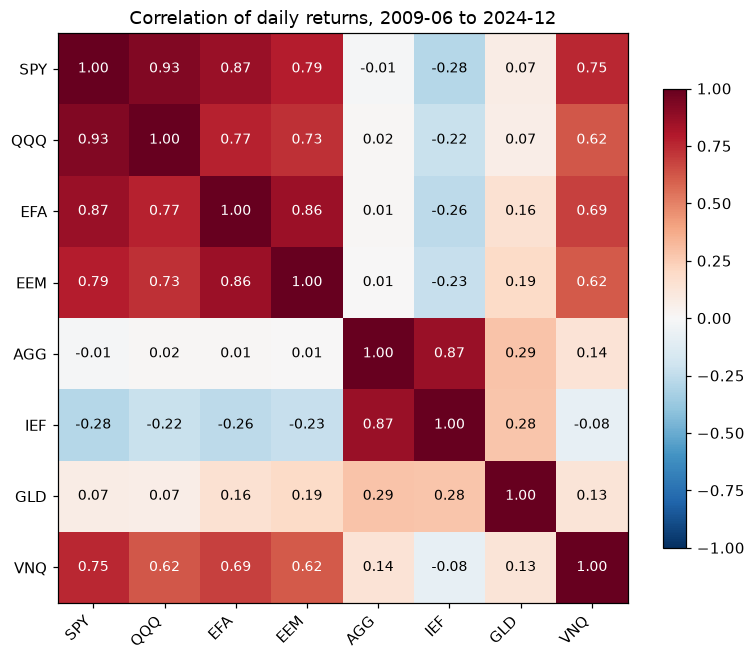

In [5]:
C = returns.dropna().corr()

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C)), C.columns, rotation=45, ha="right")
ax.set_yticks(range(len(C)), C.index)
ax.grid(False)
for i in range(len(C)):
    for j in range(len(C)):
        v = C.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else "black")
ax.set_title("Correlation of daily returns, 2009-06 to 2024-12")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

In [6]:
off = C.where(~np.eye(len(C), dtype=bool)).stack().sort_values(ascending=False)
pairs = off[::2]  # each pair appears twice
print("most-correlated pairs:")
display(pairs.head(5).rename("corr").to_frame())

worst = pairs.max()
print(f"max off-diagonal correlation = {worst:.4f}")
print(f"below the 0.95 near-duplicate threshold: {worst < 0.95}")
print(f"\nmin off-diagonal correlation = {off.min():.4f}  "
      f"({off.idxmin()[0]}/{off.idxmin()[1]} - the diversifying pair)")

most-correlated pairs:


corr
SPY QQQ  0.927553
    EFA  0.867022
AGG IEF  0.866270
EFA EEM  0.855786
EEM SPY  0.788949

max off-diagonal correlation = 0.9276
below the 0.95 near-duplicate threshold: True

min off-diagonal correlation = -0.2816  (SPY/IEF - the diversifying pair)


## 3. Per-split sample counts and the purge

Splits are assigned by the **binding (longest) label horizon**: a sample spans
`[window_end, vol_label_date]` = `[t, t+20]`, and is kept only if both ends
land in the same region. Samples straddling an internal boundary are purged,
so no training label is drawn from the validation period.

In [7]:
counts = meta["split"].value_counts().reindex(["train", "val", "test", "drop"]).fillna(0).astype(int)

rows = []
for s in ["train", "val", "test"]:
    m = meta[meta["split"] == s]
    rows.append({
        "split": s,
        "n_samples": len(m),
        "per_ticker": len(m) // len(config.UNIVERSE),
        "window_end_first": m["window_end"].min().date(),
        "window_end_last": m["window_end"].max().date(),
        "last_vol_label": m["vol_label_date"].max().date(),
        "npz_X_shape": str(splits[s]["X"].shape),
    })
summary = pd.DataFrame(rows).set_index("split")
display(summary)

print(f"dropped (purged) : {counts['drop']}")
print(f"total candidates : {int(counts.sum())}")
print(f"train is the largest split: {summary['n_samples'].idxmax() == 'train'}")
print(f"pooling factor over a single-ETF prototype: "
      f"{summary.loc['train', 'n_samples'] / summary.loc['train', 'per_ticker']:.0f}x")

,n_samples,per_ticker,window_end_first,window_end_last,last_vol_label,npz_X_shape
split,,,,,,
train,21992,2749,2010-01-04,2020-12-02,2020-12-31,"(21992, 30, 6)"
val,3864,483,2021-01-04,2022-12-01,2022-12-30,"(3864, 30, 6)"
test,3856,482,2023-01-03,2024-12-02,2024-12-31,"(3856, 30, 6)"


dropped (purged) : 896
total candidates : 30608
train is the largest split: True
pooling factor over a single-ETF prototype: 8x


In [8]:
# Where did the purged samples go? Every drop should be explainable.
from src.data.windows import region_of

ra = region_of(meta["window_end"]).to_numpy()
rb = region_of(meta["vol_label_date"]).to_numpy()
breakdown = (pd.DataFrame({"window_end_region": ra, "vol_label_region": rb,
                           "split": meta["split"].to_numpy()})
             .query("split == 'drop'")
             .groupby(["window_end_region", "vol_label_region"]).size()
             .rename("n_dropped").reset_index())
display(breakdown)

expected = config.VOL_HORIZON * len(config.UNIVERSE)
internal = breakdown.query("window_end_region in ['train', 'val']")["n_dropped"]
print(f"expected purge per internal boundary = {config.VOL_HORIZON} trading days "
      f"x {len(config.UNIVERSE)} tickers = {expected}")
print(f"observed: {list(internal)}  -> matches: {(internal == expected).all()}")
print("\nThe purge is firing. A count near zero here would mean it is not, "
      "and that train labels leak into the validation period.")

,window_end_region,vol_label_region,n_dropped
0,pre,pre,416
1,pre,train,160
2,train,val,160
3,val,test,160


expected purge per internal boundary = 20 trading days x 8 tickers = 160
observed: [160, 160]  -> matches: True

The purge is firing. A count near zero here would mean it is not, and that train labels leak into the validation period.


In [9]:
# The leakage guard itself, re-asserted from the persisted artifacts.
kept = meta["split"] != "drop"
assert (ra[kept] == rb[kept]).all(), "a kept sample straddles a split boundary"

for s in ["train", "val", "test"]:
    m = meta[meta["split"] == s]
    n_npz = splits[s]["X"].shape[0]
    assert n_npz == len(m), f"{s}: npz N={n_npz} != meta rows {len(m)}"
    assert splits[s]["X"].shape[1:] == (config.WINDOW, len(config.FEATURE_ORDER))
    assert splits[s]["y_ret"].shape == (n_npz,)
    assert splits[s]["y_vol"].shape == (n_npz,)
    assert np.isfinite(splits[s]["X"]).all()
    print(f"{s:5s}  X={splits[s]['X'].shape}  y_ret={splits[s]['y_ret'].shape}  "
          f"y_vol={splits[s]['y_vol'].shape}  meta rows={len(m)}  OK")

print("\nall shape / finiteness / no-straddle assertions passed")

train  X=(21992, 30, 6)  y_ret=(21992,)  y_vol=(21992,)  meta rows=21992  OK
val    X=(3864, 30, 6)  y_ret=(3864,)  y_vol=(3864,)  meta rows=3864  OK
test   X=(3856, 30, 6)  y_ret=(3856,)  y_vol=(3856,)  meta rows=3856  OK

all shape / finiteness / no-straddle assertions passed


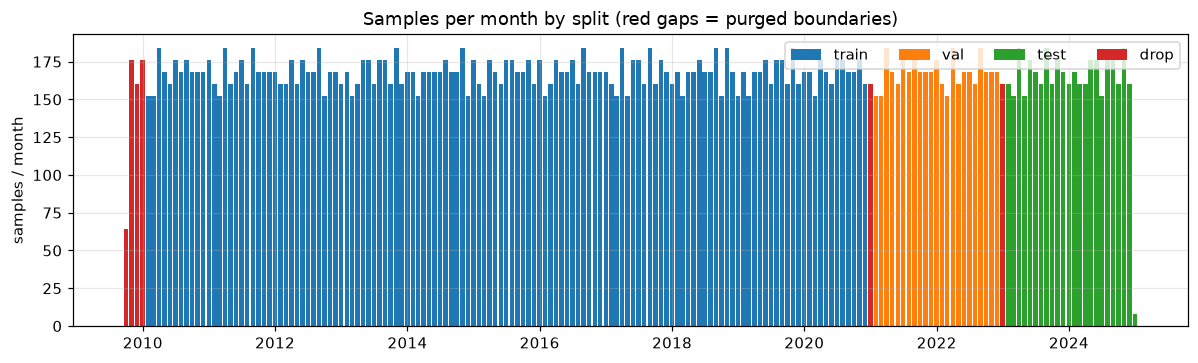

In [10]:
# Sample density over time, to confirm the purge gaps are visible and the
# pooling is balanced across sleeves.
fig, ax = plt.subplots(figsize=(11, 3.4))
colours = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "drop": "tab:red"}
for s, c in colours.items():
    m = meta[meta["split"] == s]
    monthly = m.groupby(pd.Grouper(key="window_end", freq="ME")).size()
    ax.bar(monthly.index, monthly.values, width=25, color=c, label=s)
ax.set_title("Samples per month by split (red gaps = purged boundaries)")
ax.set_ylabel("samples / month")
ax.legend(ncol=4)
fig.tight_layout()
plt.show()

## 4. Feature distributions

Rebuilt from the price panel so the shapes can be read in raw units. Expected:
`ret` centred on zero with fat tails, `vol_10` strictly non-negative and
right-skewed, `px_ma20` / `px_ma50` centred near 1.

In [11]:
feats = build_features_by_ticker(panel)
tgts  = build_targets_by_ticker(panel, config.VOL_HORIZON)

desc = pd.DataFrame({
    t: f.dropna().agg(["mean", "std", "min", "max"]).T.stack()
    for t, f in feats.items()
}).T
display(pd.DataFrame({t: f.dropna().mean() for t, f in feats.items()}).T.round(6))
print("per-ticker feature means (raw units)")

print(f"\nvol_10 minimum across all sleeves: "
      f"{min(f['vol_10'].min() for f in feats.values()):.6f}  (must be >= 0)")

,ret,vol_10,mom_5,mom_20,px_ma20,px_ma50
SPY,0.000585,0.008995,0.002951,0.012031,1.005239,1.013746
QQQ,0.000776,0.011155,0.003911,0.015817,1.006867,1.017916
EFA,0.000288,0.010076,0.001435,0.006084,1.002308,1.006282
EEM,0.000213,0.012242,0.001073,0.004613,1.001423,1.004043
AGG,0.000101,0.002486,0.000496,0.002028,1.000920,1.002424
IEF,0.000106,0.003885,0.000519,0.002094,1.000926,1.002419
GLD,0.000293,0.009003,0.001456,0.005943,1.002468,1.006460
VNQ,0.000453,0.011225,0.002350,0.010155,1.004026,1.010938


per-ticker feature means (raw units)

vol_10 minimum across all sleeves: 0.000572  (must be >= 0)


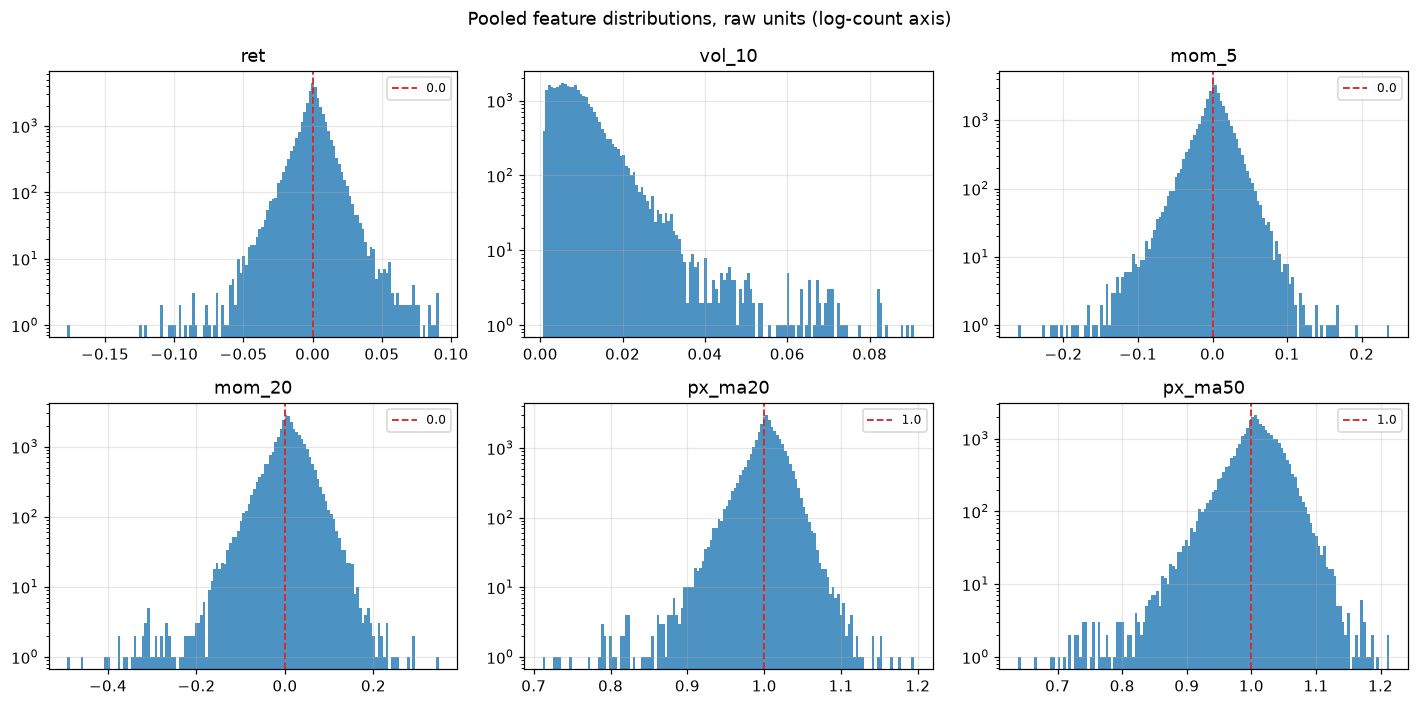

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, name in zip(axes.ravel(), config.FEATURE_ORDER):
    pooled = pd.concat([f[name].dropna() for f in feats.values()])
    ax.hist(pooled, bins=140, color="tab:blue", alpha=0.8)
    ax.set_title(name)
    ax.set_yscale("log")
    if name in ("px_ma20", "px_ma50"):
        ax.axvline(1.0, color="tab:red", lw=1.2, ls="--", label="1.0")
        ax.legend(fontsize=8)
    elif name in ("ret", "mom_5", "mom_20"):
        ax.axvline(0.0, color="tab:red", lw=1.2, ls="--", label="0.0")
        ax.legend(fontsize=8)
fig.suptitle("Pooled feature distributions, raw units (log-count axis)")
fig.tight_layout()
plt.show()

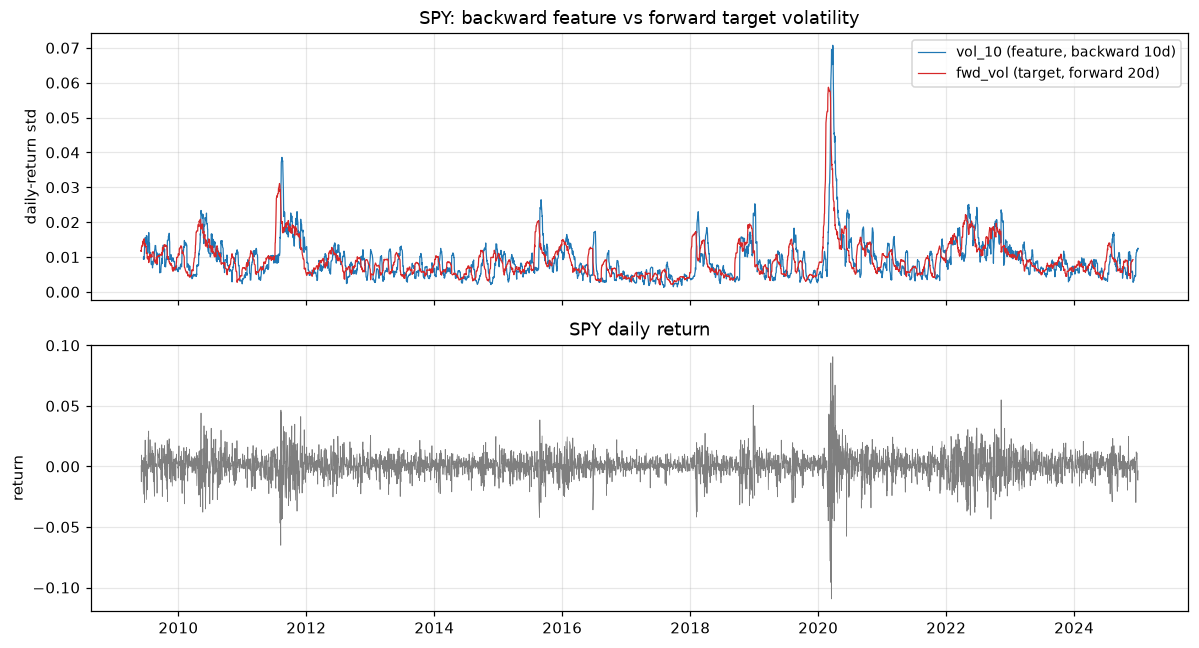

corr(fwd_vol, 20d vol already known at t) = 0.531
Well below 1.0: the target genuinely lives in the future of t.


In [13]:
# vol_10 (feature, backward-looking) against fwd_vol (target, forward-looking)
# for SPY. They track loosely - if they tracked tightly the target would
# already be known at prediction time and the forecasting task would be void.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(feats["SPY"].index, feats["SPY"]["vol_10"], lw=0.8, color="tab:blue",
         label="vol_10 (feature, backward 10d)")
ax1.plot(tgts["SPY"].index, tgts["SPY"]["fwd_vol"], lw=0.8, color="tab:red",
         label=f"fwd_vol (target, forward {config.VOL_HORIZON}d)")
ax1.set_title("SPY: backward feature vs forward target volatility")
ax1.set_ylabel("daily-return std")
ax1.legend(fontsize=9)

ax2.plot(returns.index, returns["SPY"], lw=0.5, color="tab:grey")
ax2.set_title("SPY daily return")
ax2.set_ylabel("return")
fig.tight_layout()
plt.show()

backward_20 = returns["SPY"].rolling(config.VOL_HORIZON).std(ddof=1)
print(f"corr(fwd_vol, 20d vol already known at t) = "
      f"{tgts['SPY']['fwd_vol'].corr(backward_20):.3f}")
print("Well below 1.0: the target genuinely lives in the future of t.")

In [14]:
# Scaler provenance: the statistics must come from TRAIN windows only.
stats = pd.DataFrame({"mean": scaler.mean_, "var": scaler.var_}, index=config.FEATURE_ORDER)
display(stats)

n_train = splits["train"]["X"].shape[0]
print(f"scaler.n_samples_seen_ = {int(scaler.n_samples_seen_)}")
print(f"n_train x window       = {n_train} x {config.WINDOW} = {n_train * config.WINDOW}")
assert int(scaler.n_samples_seen_) == n_train * config.WINDOW
print("-> the scaler saw exactly the train windows, and nothing from val or test")

flat = splits["train"]["X"].reshape(-1, len(config.FEATURE_ORDER))
print(f"\nscaled train mean (should be ~0): {np.abs(flat.mean(0)).max():.2e}")
print(f"scaled train std  (should be ~1): {np.abs(flat.std(0) - 1).max():.2e}")
val_mean = splits["val"]["X"].reshape(-1, len(config.FEATURE_ORDER)).mean(0)
print(f"scaled val mean (offset from 0 = genuine regime shift, not a bug):\n  "
      f"{np.round(val_mean, 3)}")

,mean,var
ret,0.000361,0.000116
vol_10,0.008449,0.000047
mom_5,0.001802,0.000513
mom_20,0.007206,0.001780
px_ma20,1.003002,0.000575
px_ma50,1.007749,0.001308


scaler.n_samples_seen_ = 659760
n_train x window       = 21992 x 30 = 659760
-> the scaler saw exactly the train windows, and nothing from val or test

scaled train mean (should be ~0): 8.22e-12
scaled train std  (should be ~1): 1.33e-13
scaled val mean (offset from 0 = genuine regime shift, not a bug):
  [-0.046  0.156 -0.112 -0.245 -0.204 -0.333]


## 5. Cross-checks for bad ticks

Two layers. The second-vendor comparison against Stooq is **best-effort**: it
is reported as unavailable rather than raising, so the pipeline stays fully
reproducible offline. The self-contained screen runs regardless.

In [15]:
cc = stooq_compare(panel, ["SPY", "AGG", "GLD"], config.FETCH_START, config.FETCH_END)
print(f"Stooq cross-check status: {cc['status']}")
if cc["status"] == "ok":
    display(cc["summary"])
    print(f"flagged dates: {len(cc['flagged'])}")
    if len(cc["flagged"]):
        display(cc["flagged"])
else:
    print("Stooq gates its CSV endpoint behind a JavaScript bot-check, and")
    print("pandas-datareader 0.11.1 has dropped its stooq module, so a second")
    print("vendor is not reachable. The self-contained screen below covers the")
    print("same class of defect using only the cached data.")
    print(f"\ndetail: {cc['error'][:160]}...")

Stooq cross-check status: unavailable
Stooq gates its CSV endpoint behind a JavaScript bot-check, and
pandas-datareader 0.11.1 has dropped its stooq module, so a second
vendor is not reachable. The self-contained screen below covers the
same class of defect using only the cached data.

detail: SPY: Stooq did not return CSV (got: '<!DOCTYPE html><html><head><meta charset="utf-8"><meta name='); AGG: Stooq did not return CSV (got: '<!DOCTYPE html><html><...


In [16]:
screen = tick_screen(prices_raw, panel)

print("Implied distributions detected (ret_adj - ret_close > 0):")
display(screen["n_distributions"].to_frame())
print("Cadence is as expected: GLD pays nothing, AGG/IEF monthly,")
print("SPY/QQQ/VNQ quarterly, EFA/EEM semi-annual.\n")

n_bad = len(screen["adj_vs_close"])
print(f"adjustment defects (negative, or > {screen['max_distribution']:.0%}): {n_bad}")
if n_bad:
    display(screen["adj_vs_close"])
else:
    print("-> none: every adjusted/unadjusted divergence is a real distribution.")

Implied distributions detected (ret_adj - ret_close > 0):


,n_distributions
SPY,63
QQQ,66
EFA,33
EEM,36
AGG,187
IEF,187
GLD,0
VNQ,63


Cadence is as expected: GLD pays nothing, AGG/IEF monthly,
SPY/QQQ/VNQ quarterly, EFA/EEM semi-annual.

adjustment defects (negative, or > 5%): 0
-> none: every adjusted/unadjusted divergence is a real distribution.


In [17]:
print(f"observations beyond |z| > {screen['z_threshold']} (robust median/MAD): "
      f"{screen['n_extreme_total']}")
print(f"of which NO other sleeve corroborates: {len(screen['isolated_moves'])}\n")
display(screen["isolated_moves"])
print("Both isolated moves are well-documented real events, not bad ticks:")
print("  AGG 2020-03-19  COVID Treasury/credit dislocation and the Fed backstop")
print("  GLD 2013-04-15  the April 2013 gold crash (-9% in a session)")
print("\nNothing egregious. No observation is excluded on this basis.")

observations beyond |z| > 8.0 (robust median/MAD): 39
of which NO other sleeve corroborates: 2



,ticker,date,ret,robust_z,other_sleeves_moving
0,AGG,2020-03-19,0.022333,10.119281,0
1,GLD,2013-04-15,-0.087808,-11.548434,0


Both isolated moves are well-documented real events, not bad ticks:
  AGG 2020-03-19  COVID Treasury/credit dislocation and the Fed backstop
  GLD 2013-04-15  the April 2013 gold crash (-9% in a session)

Nothing egregious. No observation is excluded on this basis.


## 6. Summary

| check | result |
|---|---|
| coverage | 8/8 tickers, 3924 rows each, 2009-06-01 to 2024-12-31, no gap > 5 business days |
| alignment | inner join drops 0 dates; all 8 sleeves already share one calendar |
| leakage (features) | every feature at `t` reproducible by hand from `Adj Close <= t` |
| leakage (splits) | every kept sample has `region(window_end) == region(vol_label_date)` |
| purge | 160 = 20d x 8 tickers at each internal boundary; 576 pre-2010 warmup samples |
| distinctness | max pairwise return correlation 0.928 (SPY/QQQ), below the 0.95 threshold |
| scaler | fitted on 21,992 x 30 = 659,760 train rows only |
| bad ticks | 0 adjustment defects; 2 isolated moves, both real market events |
| reproducibility | rebuild is bitwise identical (X, meta, scaler statistics) |

The dataset is ready for the LSTM forecaster (`train/val/test.npz`) and for the
optimiser, baselines, and backtester (`prices.parquet`, `returns.parquet`).